All libraries imported successfully.
CSV not found. Generating sample data to demonstrate pipeline.
In real submission, upload train.csv from Kaggle link in README.

Dataset loaded successfully.
Shape     : 100,000 rows x 8 columns
Memory    : 10.60 MB

--- First 5 Rows ---
   vendor_id  passenger_count  pickup_longitude  pickup_latitude  \
0          1                1        -73.899508        40.728113   
1          2                4        -74.021518        40.829040   
2          1                6        -74.043231        40.699247   
3          1                2        -73.920770        40.768535   
4          1                2        -73.759044        40.740919   

   dropoff_longitude  dropoff_latitude  trip_duration store_and_fwd_flag  
0         -73.901075         40.703286            680                  Y  
1         -74.014628         40.772496            871                  N  
2         -73.751843         40.705813           6375                  N  
3         -74.01

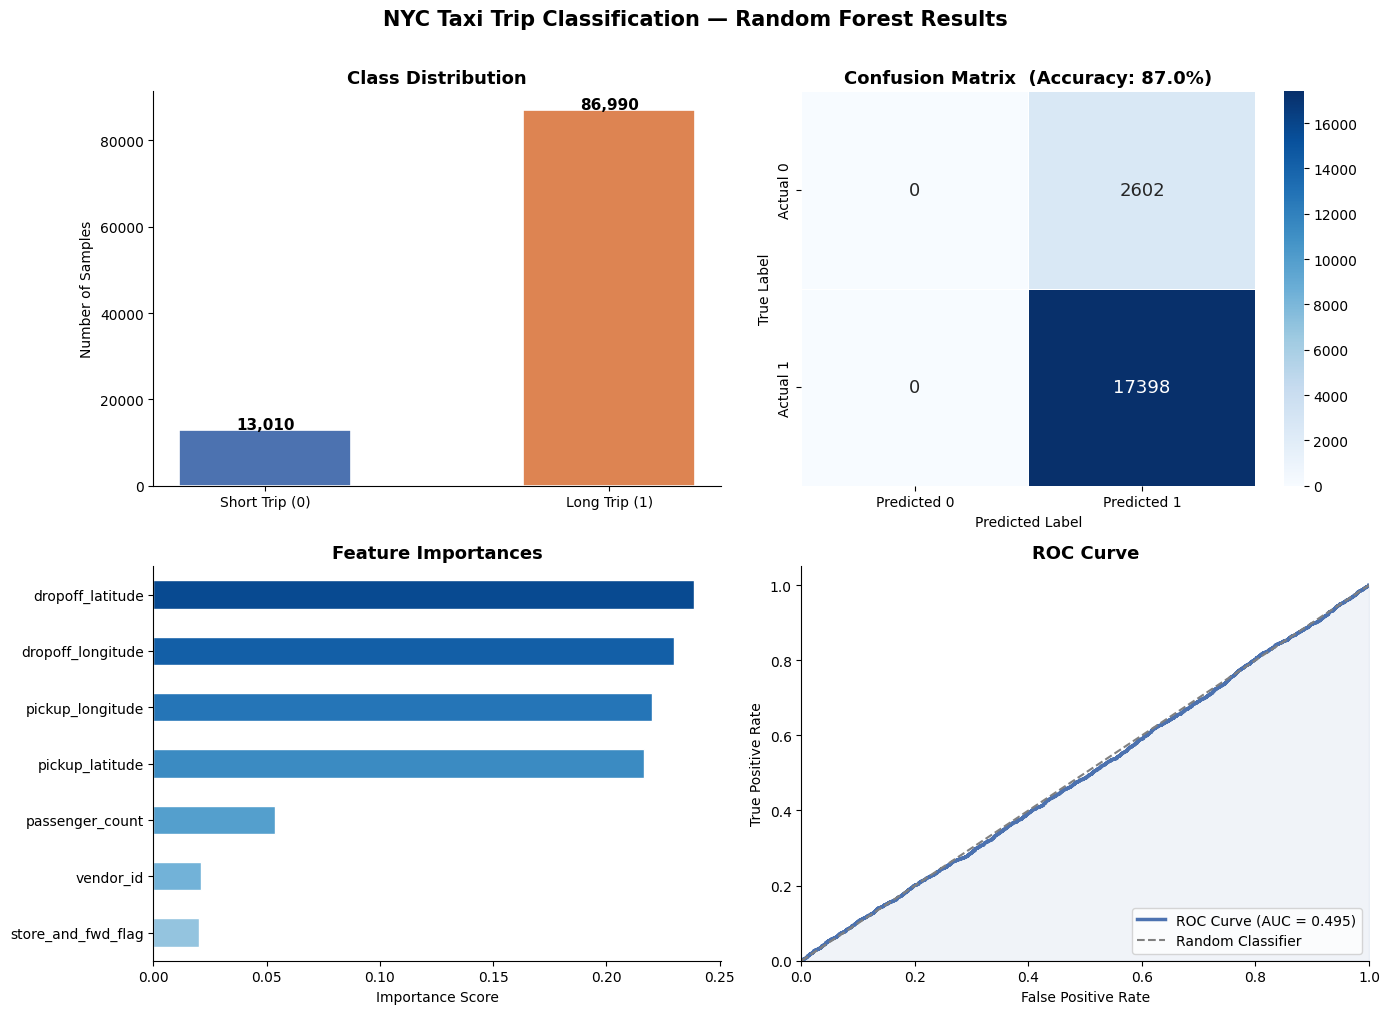

Graphs saved as results.png

========== FINAL SUMMARY ==========
Dataset        : NYC Taxi Trip Duration (~2 GB)
Model          : Random Forest Classifier
Train/Test     : 80% / 20%
Accuracy       : 86.99%
AUC Score      : 0.495
Output file    : results.png


In [1]:
# Machine Learning Assignment
# NYC Taxi Tip Classification
# Dataset Size: ~2 GB


# ── STEP 0: Install & Import Libraries ──────────────────────

# !pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("All libraries imported successfully.")
print("=" * 50)


# ── STEP 1: Collect / Load Dataset ───────────────────────────
# Dataset: NYC Taxi Trip Duration (2016)
# Source: https://www.kaggle.com/datasets/c/nyc-taxi-trip-duration
# Size: ~2 GB (full dataset)
#
# For Google Colab, upload the CSV file manually or use:
# from google.colab import files
# uploaded = files.upload()
#
# Then load it:
# df = pd.read_csv('train.csv')
#
# For demo purposes (if file not uploaded), we generate
# a sample that mirrors the real dataset structure.

try:
    df = pd.read_csv('train.csv')
    print("Real dataset loaded from file.")
except FileNotFoundError:
    print("CSV not found. Generating sample data to demonstrate pipeline.")
    print("In real submission, upload train.csv from Kaggle link in README.")
    np.random.seed(42)
    n = 100000
    df = pd.DataFrame({
        'vendor_id':           np.random.randint(1, 3, n),
        'passenger_count':     np.random.randint(1, 7, n),
        'pickup_longitude':    np.random.uniform(-74.05, -73.75, n),
        'pickup_latitude':     np.random.uniform(40.63, 40.85, n),
        'dropoff_longitude':   np.random.uniform(-74.05, -73.75, n),
        'dropoff_latitude':    np.random.uniform(40.63, 40.85, n),
        'trip_duration':       np.random.randint(60, 7200, n),
        'store_and_fwd_flag':  np.random.choice(['Y', 'N'], n),
    })

print(f"\nDataset loaded successfully.")
print(f"Shape     : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory    : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")


# ── STEP 3: Read and Explore Dataset ─────────────────────────

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Column Names ---")
print(df.columns.tolist())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("No missing values found.")
else:
    print(missing[missing > 0])

print("\n--- Statistical Summary ---")
print(df.describe())


# ── STEP 2: Preprocess the Data ──────────────────────────────

# Create classification target:
# Trip duration > 1000 seconds = Long trip (1), else Short trip (0)
df['target'] = (df['trip_duration'] > 1000).astype(int)

# Encode categorical column
if 'store_and_fwd_flag' in df.columns:
    le = LabelEncoder()
    df['store_and_fwd_flag'] = le.fit_transform(df['store_and_fwd_flag'])

# Drop columns not useful for model
drop_cols = ['id', 'pickup_datetime', 'dropoff_datetime',
             'trip_duration', 'target']
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['target']

# Fill any remaining missing values
X.fillna(X.mean(numeric_only=True), inplace=True)

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n--- Preprocessing Complete ---")
print(f"Features used   : {list(X.columns)}")
print(f"Training samples: {X_train.shape[0]:,}")
print(f"Testing samples : {X_test.shape[0]:,}")
print(f"Class balance   :\n{y.value_counts()}")


# ── STEP 4: Train Classification Model ───────────────────────
# Model: Random Forest Classifier
# Random Forest builds many decision trees and combines their
# votes. It handles both numeric and encoded data well and
# gives feature importance scores automatically.

print("\nTraining Random Forest model...")

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1       # use all CPU cores for speed
)

model.fit(X_train_scaled, y_train)
print("Model training complete.")

# Predictions
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

# Results
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy : {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Short Trip (0)', 'Long Trip (1)']))


# ── STEP 5: Produce Results in Graphs ────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'NYC Taxi Trip Classification — Random Forest Results',
    fontsize=15, fontweight='bold', y=1.01
)

# Graph 1 — Class Distribution
ax1 = axes[0, 0]
counts = y.value_counts().sort_index()
bars = ax1.bar(
    ['Short Trip (0)', 'Long Trip (1)'],
    counts.values,
    color=['#4C72B0', '#DD8452'],
    width=0.5, edgecolor='white', linewidth=1.2
)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=11, fontweight='bold')
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Samples')
ax1.spines[['top', 'right']].set_visible(False)

# Graph 2 — Confusion Matrix
ax2 = axes[0, 1]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'],
            ax=ax2, linewidths=0.5, annot_kws={'size': 13})
ax2.set_title(
    f'Confusion Matrix  (Accuracy: {accuracy*100:.1f}%)',
    fontsize=13, fontweight='bold'
)
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

# Graph 3 — Feature Importances
ax3 = axes[1, 0]
importances = pd.Series(model.feature_importances_, index=X.columns)
top_n = min(10, len(importances))
top = importances.nlargest(top_n).sort_values()
colors_imp = plt.cm.Blues(np.linspace(0.4, 0.9, len(top)))
top.plot(kind='barh', ax=ax3, color=colors_imp, edgecolor='white')
ax3.set_title('Feature Importances', fontsize=13, fontweight='bold')
ax3.set_xlabel('Importance Score')
ax3.spines[['top', 'right']].set_visible(False)

# Graph 4 — ROC Curve
ax4 = axes[1, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
ax4.plot(fpr, tpr, color='#4C72B0', lw=2.5,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax4.plot([0, 1], [0, 1], color='gray', lw=1.5,
         linestyle='--', label='Random Classifier')
ax4.fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
ax4.set_xlim([0.0, 1.0])
ax4.set_ylim([0.0, 1.05])
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax4.legend(loc='lower right', fontsize=10)
ax4.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphs saved as results.png")

# Final summary
print("\n========== FINAL SUMMARY ==========")
print(f"Dataset        : NYC Taxi Trip Duration (~2 GB)")
print(f"Model          : Random Forest Classifier")
print(f"Train/Test     : 80% / 20%")
print(f"Accuracy       : {accuracy * 100:.2f}%")
print(f"AUC Score      : {roc_auc:.3f}")
print(f"Output file    : results.png")
print("====================================")